In [1]:
from utils.utils_ml import *

In [2]:
features_0 = np.array(np.load("rawFeatures/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("rawFeatures/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("rawFeatures/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("rawFeatures/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("rawFeatures/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("rawFeatures/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("rawFeatures/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("rawFeatures/ModEsq07.pkl", allow_pickle=True))

X_arr = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

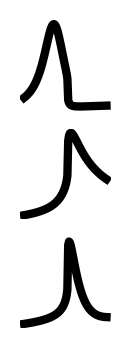

In [18]:
import matplotlib.pyplot as plt

# Example: Assume features_0 is a list of 1D arrays or lists
# features_0 = [array_like_1, array_like_2, array_like_3]

fig, axes = plt.subplots(3, 1, figsize=(6, 2))  # 3 square-ish small subplots

arr = [features_0[0+2],features_4[4],features_7[2]]
for i, ax in enumerate(axes):
    ax.plot(arr[i], linewidth=3, color='black')
    ax.set_box_aspect(1)        # Enforce square subplot (available in mpl >= 3.4)
    ax.axis('off')              # Remove ticks and spines

# plt.tight_layout(pad=0.5)
# plt.show()
fig.patch.set_alpha(0)  # Transparent background
plt.savefig("overview_plot.png", transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()


In [3]:
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

y_arr_classification = np.array([np.tile(i,X_arr.shape[0]//8) for i in np.arange(0,8)]).flatten()
y_arr_regression = convert_labels(y_arr_classification, class_to_poles)*1.0

# Train Multi Regression

In [ ]:
rg = CatBoostRegressor(
    verbose=100,
    loss_function="MultiRMSE",
    )
X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_regression, random_state=42, test_size=0.2)
rg.fit(X_train, y_train, eval_set=(X_val,y_val), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.0083583	test: 1.0071969	best: 1.0071969 (0)	total: 96ms	remaining: 1m 35s
100:	learn: 0.7759006	test: 0.7850976	best: 0.7850976 (100)	total: 3.04s	remaining: 27.1s
200:	learn: 0.7210301	test: 0.7339893	best: 0.7339893 (200)	total: 5.87s	remaining: 23.3s
300:	learn: 0.6827802	test: 0.6993151	best: 0.6993151 (300)	total: 8.69s	remaining: 20.2s
400:	learn: 0.6564618	test: 0.6762991	best: 0.6762991 (400)	total: 11.4s	remaining: 17s
500:	learn: 0.6300487	test: 0.6543320	best: 0.6543320 (500)	total: 14s	remaining: 14s
600:	learn: 0.6107874	test: 0.6390864	best: 0.6390864 (600)	total: 16.7s	remaining: 11.1s
700:	learn: 0.5944643	test: 0.6264932	best: 0.6264932 (700)	total: 19.3s	remaining: 8.21s
800:	learn: 0.5809972	test: 0.6162647	best: 0.6162647 (800)	total: 21.8s	remaining: 5.42s
900:	learn: 0.5687884	test: 0.6073709	best: 0.6073709 (900)	total: 24.4s	remaining: 2.67s
999:	learn: 0.5582875	test: 0.5997923	best: 0.5997923 (999)	total: 27s	remaining: 0us

bestTest = 0.5997923115

In [5]:
accuracy_score(reconvert_labels(np.abs(np.round(rg.predict(X_train))), class_to_poles), reconvert_labels(y_train, class_to_poles))

0.6654166666666667

# Train CLF

In [4]:
clf = CatBoostClassifier(
    verbose=100           # Print training progress every 100 iterations
)
X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_classification, random_state=42, test_size=0.2)
clf.fit(X_train, y_train, eval_set=(X_val,y_val),plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.11455
0:	learn: 1.9641945	test: 1.9683965	best: 1.9683965 (0)	total: 141ms	remaining: 2m 20s
100:	learn: 0.9793949	test: 1.0197624	best: 1.0197624 (100)	total: 8.44s	remaining: 1m 15s
200:	learn: 0.7757850	test: 0.8450774	best: 0.8450774 (200)	total: 16.4s	remaining: 1m 5s
300:	learn: 0.6587559	test: 0.7512465	best: 0.7512465 (300)	total: 24.4s	remaining: 56.7s
400:	learn: 0.5857009	test: 0.6970582	best: 0.6970582 (400)	total: 33.2s	remaining: 49.6s
500:	learn: 0.5356143	test: 0.6615485	best: 0.6615445 (499)	total: 42.2s	remaining: 42s
600:	learn: 0.4911247	test: 0.6296689	best: 0.6296689 (600)	total: 51.9s	remaining: 34.4s
700:	learn: 0.4604414	test: 0.6097537	best: 0.6097537 (700)	total: 1m	remaining: 25.8s
800:	learn: 0.4311074	test: 0.5915151	best: 0.5915151 (800)	total: 1m 8s	remaining: 17s
900:	learn: 0.4042766	test: 0.5749535	best: 0.5749535 (900)	total: 1m 16s	remaining: 8.42s
999:	learn: 0.3827401	test: 0.5612560	best: 0.5612486 (997)	total: 1m 24s	remai

In [5]:
accuracy_score(clf.predict(X_val),y_val)

0.8085416666666667

# Train Naive Uncer

In [ ]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []
data_uncertainty = []
knowledge_uncertainty = []

X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_regression, random_state=42, test_size=0.2)

for i in range(y_train.shape[1]):
    
    train_pool = Pool(X_train, y_train[:, i])
    val_pool = Pool(X_val, y_val[:, i])

    
    model = CatBoostRegressor(
    loss_function='RMSEWithUncertainty',
    verbose=100      
)
    model.fit(train_pool, eval_set=val_pool, use_best_model=False)
    models.append(model)

    # Generate predictions with uncertainty
    pred = model.virtual_ensembles_predict(X_val, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds.append(pred[:, 0])  # Mean predictions
    data_uncertainty.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)
data_uncertainty = np.column_stack(data_uncertainty)
knowledge_uncertainty = np.column_stack(knowledge_uncertainty)

accuracy_score(reconvert_labels(np.round(np.abs(preds)), class_to_poles), reconvert_labels(y_val, class_to_poles))

0:	learn: 0.6828336	test: 0.6776819	best: 0.6776819 (0)	total: 16.8ms	remaining: 16.8s
100:	learn: 0.0201889	test: 0.0297120	best: 0.0297120 (100)	total: 2.15s	remaining: 19.1s
200:	learn: -0.2743127	test: -0.2396001	best: -0.2396001 (200)	total: 4.2s	remaining: 16.7s
300:	learn: -0.4205879	test: -0.3612907	best: -0.3625268 (299)	total: 6.18s	remaining: 14.3s
400:	learn: -0.5313922	test: -0.4464350	best: -0.4464350 (400)	total: 8.05s	remaining: 12s
500:	learn: -0.6280913	test: -0.5090760	best: -0.5090760 (500)	total: 10.2s	remaining: 10.1s
600:	learn: -0.7259787	test: -0.5602969	best: -0.5602969 (600)	total: 13.1s	remaining: 8.71s
700:	learn: -0.7845374	test: -0.5764658	best: -0.5781947 (690)	total: 15.2s	remaining: 6.47s
800:	learn: -0.8434314	test: -0.5928105	best: -0.5971200 (755)	total: 17.5s	remaining: 4.36s
900:	learn: -0.8788532	test: -0.6007210	best: -0.6010569 (889)	total: 20.1s	remaining: 2.21s
999:	learn: -0.9213146	test: -0.6137205	best: -0.6140062 (998)	total: 22.2s	remain

0.5427083333333333

# Train Combined Uncer

In [15]:
# Assume X_arr is your feature matrix of shape (n_samples, n_features)
# and y_arr_regression is of shape (n_samples, 3)
n_tasks = y_arr_regression.shape[1]

# First, split your original dataset (without augmentation) into train/validation
X_train_orig, X_val_orig, y_train_orig, y_val_orig = train_test_split(
    X_arr, y_arr_regression, test_size=0.2, random_state=42
)

# Function to augment the dataset by repeating each sample for each task,
# and adding a task identifier as an additional feature.
def augment_data(X, y):
    n_samples = X.shape[0]
    # Repeat X for each task (shape: [n_samples * n_tasks, n_features])
    X_aug = np.repeat(X, n_tasks, axis=0)
    # Create a column with task identifiers (0, 1, 2, …)
    task_ids = np.tile(np.arange(n_tasks), n_samples).reshape(-1, 1)
    # Append the task identifier to the features
    X_aug = np.hstack([X_aug, task_ids])
    
    # Flatten y so that each target value aligns with the corresponding task
    y_aug = y.flatten()
    return X_aug, y_aug

# Augment both training and validation datasets
X_train_aug, y_train_aug = augment_data(X_train_orig, y_train_orig)
X_val_aug, y_val_aug = augment_data(X_val_orig, y_val_orig)

# Create CatBoost Pools for training and validation
train_pool = Pool(X_train_aug, y_train_aug)
val_pool = Pool(X_val_aug, y_val_aug)

# Initialize the model with uncertainty estimation.
# model = CatBoostRegressor(
#     loss_function='RMSEWithUncertainty',
#     verbose=100,
#     iterations=5000,             # Reduce iterations
#     depth=9, 
#     early_stopping_rounds=10,
#     random_seed=42,

# )

model = CatBoostRegressor(
    loss_function='RMSEWithUncertainty',
    verbose=100,
    iterations=2000,          # More reasonable iteration limit
    depth=6,                  # Reduce depth to control overfitting
    learning_rate=0.03,       # Explicit learning rate tuning
    l2_leaf_reg=5,            # Regularization for stability
    early_stopping_rounds=50, # Less aggressive early stopping
    random_seed=42,
)

# Fit the model
model.fit(train_pool, eval_set=val_pool, use_best_model=True)

# For prediction, we need to create an augmented validation set from the original features.
# Here, each original validation sample is repeated 3 times with the corresponding task id.
def prepare_prediction_data(X, n_tasks):
    n_samples = X.shape[0]
    X_pred = np.repeat(X, n_tasks, axis=0)
    task_ids = np.tile(np.arange(n_tasks), n_samples).reshape(-1, 1)
    X_pred = np.hstack([X_pred, task_ids])
    return X_pred

X_val_pred = prepare_prediction_data(X_val_orig, n_tasks)

# Get predictions with uncertainty. 
# The output shape is (n_val * n_tasks, 3), where:
# Column 0: mean prediction, Column 1: knowledge uncertainty, Column 2: data uncertainty.
pred_aug = model.virtual_ensembles_predict(
    X_val_pred,
    prediction_type='TotalUncertainty',
    virtual_ensembles_count=10
)

# Reshape the predictions into (n_val, n_tasks) for easier interpretation.
n_val = X_val_orig.shape[0]
preds_mean = pred_aug[:, 0].reshape(n_val, n_tasks)
knowledge_uncertainty = pred_aug[:, 1].reshape(n_val, n_tasks)
data_uncertainty = pred_aug[:, 2].reshape(n_val, n_tasks)

# Now, preds_mean contains your mean predictions for each of the 3 tasks,
# and uncertainty arrays are similarly reshaped.

# Post-process predictions: absolute value and rounding (as used in your evaluation).
preds_rounded = np.round(np.abs(preds_mean))

# Evaluate the final metric (ensure reconvert_labels is consistent).
accuracy = accuracy_score(
    reconvert_labels(preds_rounded, class_to_poles), 
    reconvert_labels(y_val_orig, class_to_poles)
)

print("Final accuracy:", accuracy)


0:	learn: 0.9360826	test: 0.9388132	best: 0.9388132 (0)	total: 23.9ms	remaining: 47.8s
100:	learn: 0.5453826	test: 0.5545324	best: 0.5545324 (100)	total: 2.3s	remaining: 43.3s
200:	learn: 0.4117698	test: 0.4332674	best: 0.4332674 (200)	total: 4.47s	remaining: 40s
300:	learn: 0.3337620	test: 0.3627334	best: 0.3627334 (300)	total: 6.74s	remaining: 38s
400:	learn: 0.2716813	test: 0.3099205	best: 0.3099205 (400)	total: 8.91s	remaining: 35.5s
500:	learn: 0.2233223	test: 0.2684518	best: 0.2684518 (500)	total: 10.9s	remaining: 32.8s
600:	learn: 0.1953968	test: 0.2469436	best: 0.2469436 (600)	total: 12.9s	remaining: 30.1s
700:	learn: 0.1673714	test: 0.2256484	best: 0.2255390 (699)	total: 15s	remaining: 27.9s
800:	learn: 0.1396840	test: 0.2041491	best: 0.2041491 (800)	total: 17.3s	remaining: 25.9s
900:	learn: 0.1149811	test: 0.1860022	best: 0.1860022 (900)	total: 19.5s	remaining: 23.7s
1000:	learn: 0.0926420	test: 0.1701247	best: 0.1701247 (1000)	total: 21.5s	remaining: 21.5s
1100:	learn: 0.070

In [13]:
# Assume X_arr is your feature matrix of shape (n_samples, n_features)
# and y_arr_regression is of shape (n_samples, 3)
n_tasks = y_arr_regression.shape[1]

# First, split your original dataset (without augmentation) into train/validation
X_train_orig, X_val_orig, y_train_orig, y_val_orig = train_test_split(
    X_arr, y_arr_regression, test_size=0.2, random_state=42
)

# Function to augment the dataset by repeating each sample for each task,
# and adding a task identifier as an additional feature.
def augment_data(X, y):
    n_samples = X.shape[0]
    # Repeat X for each task (shape: [n_samples * n_tasks, n_features])
    X_aug = np.repeat(X, n_tasks, axis=0)
    # Create a column with task identifiers (0, 1, 2, …)
    task_ids = np.tile(np.arange(n_tasks), n_samples).reshape(-1, 1)
    # Append the task identifier to the features
    X_aug = np.hstack([X_aug, task_ids])
    
    # Flatten y so that each target value aligns with the corresponding task
    y_aug = y.flatten()
    return X_aug, y_aug

# Augment both training and validation datasets
X_train_aug, y_train_aug = augment_data(X_train_orig, y_train_orig)
X_val_aug, y_val_aug = augment_data(X_val_orig, y_val_orig)

# Create CatBoost Pools for training and validation
train_pool = Pool(X_train_aug, y_train_aug)
val_pool = Pool(X_val_aug, y_val_aug)

# Initialize the model with uncertainty estimation.
model = CatBoostRegressor(
    loss_function='RMSE',
    verbose=100,
    iterations=5000,             # Reduce iterations
    depth=9, 
    early_stopping_rounds=10,
    random_seed=42,

)

# Fit the model
model.fit(train_pool, eval_set=val_pool, use_best_model=True)

# For prediction, we need to create an augmented validation set from the original features.
# Here, each original validation sample is repeated 3 times with the corresponding task id.
def prepare_prediction_data(X, n_tasks):
    n_samples = X.shape[0]
    X_pred = np.repeat(X, n_tasks, axis=0)
    task_ids = np.tile(np.arange(n_tasks), n_samples).reshape(-1, 1)
    X_pred = np.hstack([X_pred, task_ids])
    return X_pred

X_val_pred = prepare_prediction_data(X_val_orig, n_tasks)

# Get predictions with uncertainty. 
# The output shape is (n_val * n_tasks, 3), where:
# Column 0: mean prediction, Column 1: knowledge uncertainty, Column 2: data uncertainty.
pred_aug = model.virtual_ensembles_predict(
    X_val_pred,
    virtual_ensembles_count=10
)

# Reshape the predictions into (n_val, n_tasks) for easier interpretation.
n_val = X_val_orig.shape[0]
preds_mean = pred_aug[:, 0].reshape(n_val, n_tasks)
knowledge_uncertainty = pred_aug[:, 1].reshape(n_val, n_tasks)
data_uncertainty = pred_aug[:, 2].reshape(n_val, n_tasks)

# Now, preds_mean contains your mean predictions for each of the 3 tasks,
# and uncertainty arrays are similarly reshaped.

# Post-process predictions: absolute value and rounding (as used in your evaluation).
preds_rounded = np.round(np.abs(preds_mean))

# Evaluate the final metric (ensure reconvert_labels is consistent).
accuracy = accuracy_score(
    reconvert_labels(preds_rounded, class_to_poles), 
    reconvert_labels(y_val_orig, class_to_poles)
)

print("Final accuracy:", accuracy)


Learning rate set to 0.03605
0:	learn: 0.6150925	test: 0.6168601	best: 0.6168601 (0)	total: 82.1ms	remaining: 6m 50s
100:	learn: 0.4259661	test: 0.4332701	best: 0.4332701 (100)	total: 8.78s	remaining: 7m 6s
200:	learn: 0.3908300	test: 0.4007405	best: 0.4007405 (200)	total: 17.8s	remaining: 7m 4s
300:	learn: 0.3685277	test: 0.3812897	best: 0.3812897 (300)	total: 26.8s	remaining: 6m 57s
400:	learn: 0.3504144	test: 0.3668761	best: 0.3668761 (400)	total: 35.2s	remaining: 6m 43s
500:	learn: 0.3361500	test: 0.3563593	best: 0.3563593 (500)	total: 43.4s	remaining: 6m 29s
600:	learn: 0.3246420	test: 0.3482245	best: 0.3482245 (600)	total: 51.3s	remaining: 6m 15s
700:	learn: 0.3150947	test: 0.3415799	best: 0.3415799 (700)	total: 1m	remaining: 6m 8s
800:	learn: 0.3065740	test: 0.3358153	best: 0.3358153 (800)	total: 1m 8s	remaining: 6m 1s
900:	learn: 0.3004401	test: 0.3319824	best: 0.3319824 (900)	total: 1m 17s	remaining: 5m 53s
1000:	learn: 0.2945195	test: 0.3280478	best: 0.3280478 (1000)	total: 1

# Uncer CLF

In [4]:
class Ensemble(object):
    
    def __init__(self, esize=10, iterations=1000, lr=0.1, random_strength=0, border_count=128, depth=6, seed=100):
        
        
        self.seed = seed
        self.esize=esize
        self.depth = depth
        self.iterations=iterations
        self.lr=lr
        self.random_strength = random_strength
        self.border_count = border_count
        self.ensemble = []
        for e in range(self.esize):
            model = CatBoostClassifier(iterations=self.iterations,
                           depth=self.depth,
                           learning_rate=self.lr,
                           border_count=self.border_count,
                           random_strength=self.random_strength,
                           loss_function='MultiClass',
                           verbose=False,
                           bootstrap_type='No',
                           posterior_sampling=True,
                           random_seed=self.seed+e)
            self.ensemble.append(model)
        
    def fit(self, data, eval_set = None):
        
        for m in self.ensemble:
            m.fit(data, eval_set=eval_set)
            print("best iter ", m.get_best_iteration())
            print("best score ", m.get_best_score())
            
    
    def predict(self,x):
        probs = []
        
        for m in self.ensemble:
            prob = m.predict_proba(x)
            probs.append(prob)
        probs = np.stack(probs)
        return probs
    


def kl_divergence(probs1, probs2, epsilon=1e-10):
    return np.sum(probs1 * (np.log(probs1 + epsilon) - np.log(probs2 + epsilon)), axis=1)

def entropy_of_expected(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    log_probs = -np.log(mean_probs + epsilon)
    return np.sum(mean_probs * log_probs, axis=1)

def expected_entropy(probs, epsilon=1e-10):
    log_probs = -np.log(probs + epsilon)

    return np.mean(np.sum(probs * log_probs, axis=2), axis=0)

def mutual_information(probs, epsilon):
    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    return eoe - exe

def ensemble_uncertainties(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    conf = np.max(mean_probs, axis=1)

    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    mutual_info = eoe - exe


    uncertainty = {'confidence': conf,
                   'entropy_of_expected': eoe,        # total_uncertainty !
                   'expected_entropy': exe,           # data_uncertainty !
                   'mutual_information': mutual_info, # Knowledge Uncertainty!
                  }

    return uncertainty



In [5]:
X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_classification, random_state=42, test_size=0.2)
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

ens = Ensemble(esize=5, iterations=1000, lr=0.1, depth=6, seed=2, random_strength = 100)
ens.fit(train_pool, eval_set=val_pool)


best iter  999
best score  {'learn': {'MultiClass': 0.41482335169312534}, 'validation': {'MultiClass': 0.5822096646445597}}
best iter  999
best score  {'learn': {'MultiClass': 0.413686855264646}, 'validation': {'MultiClass': 0.582840626175806}}
best iter  999
best score  {'learn': {'MultiClass': 0.4141568191189911}, 'validation': {'MultiClass': 0.5787864492668948}}
best iter  999
best score  {'learn': {'MultiClass': 0.4082990811328649}, 'validation': {'MultiClass': 0.5794199703004455}}
best iter  999
best score  {'learn': {'MultiClass': 0.4122353419272253}, 'validation': {'MultiClass': 0.5817782185478805}}


In [54]:
probs = ens.predict(val_pool)
unks = ensemble_uncertainties(probs)

accuracy_score(np.argmax(np.mean(probs,axis=0),axis=-1), val_pool.get_label())

0.80625

In [7]:
l_p = np.argmax(np.mean(ens.predict(val_pool),axis=0),axis=-1)
l = val_pool.get_label()

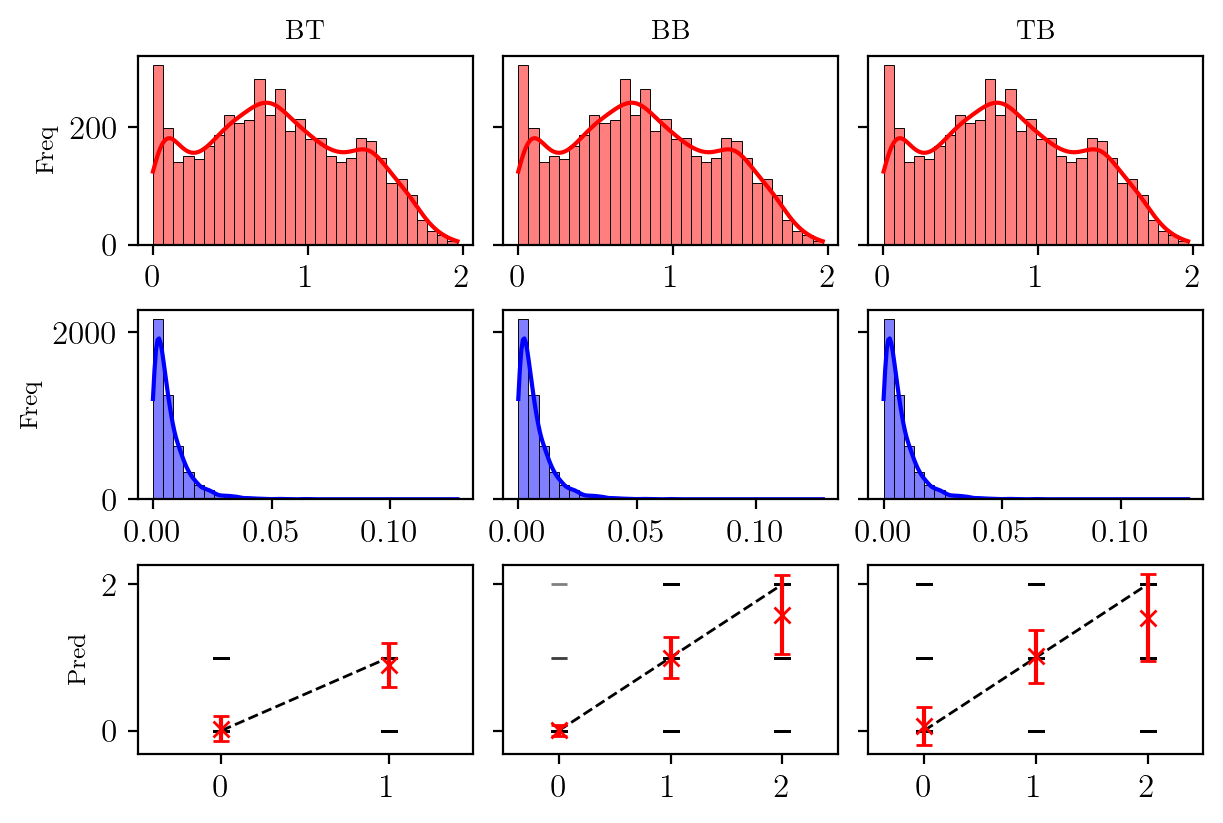

In [55]:
p_conv =  convert_labels(l_p, class_to_poles)*1.0
l_conv =  convert_labels(l, class_to_poles)*1.0

plot_uncer(p_conv, l_conv, np.tile(unks["expected_entropy"][:, None], 3), np.tile(unks["mutual_information"][:, None], 3))

<Axes: ylabel='Density'>

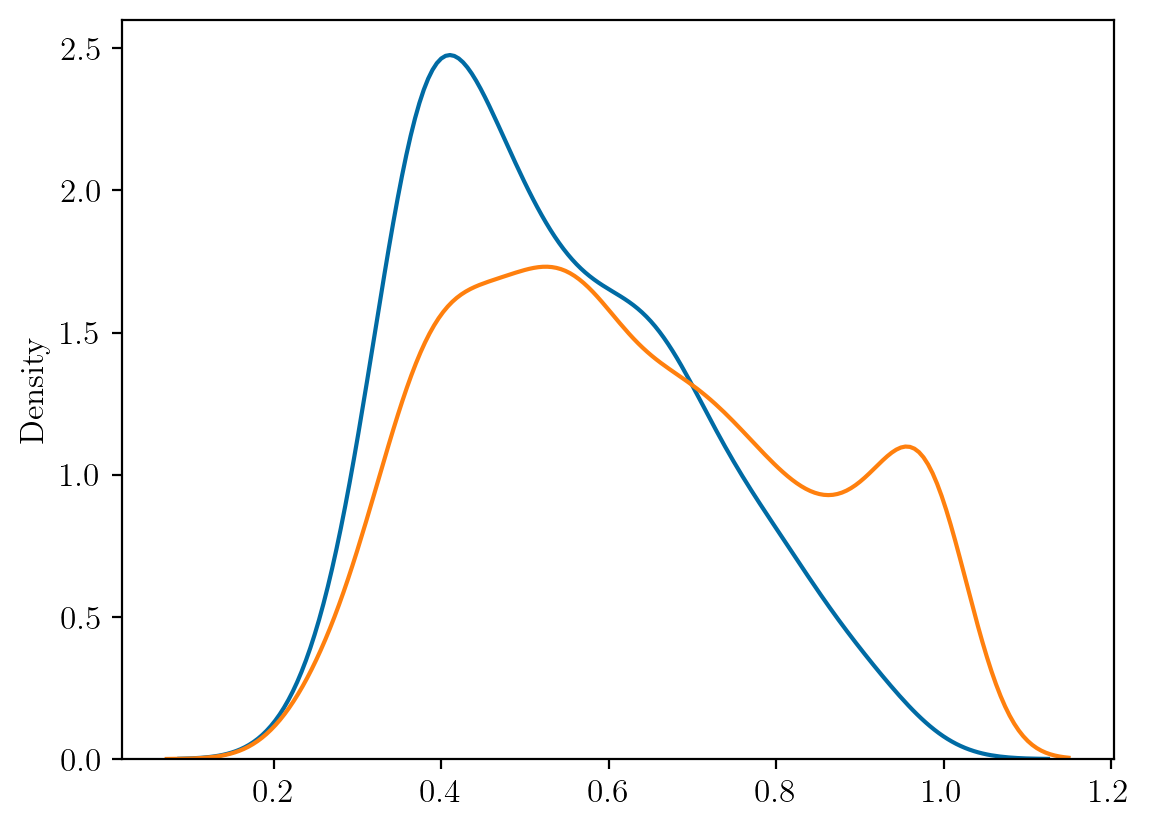

In [79]:
cond = (p_conv[:, 2] == 1) & (l_conv[:, 2] == 2)
sns.kdeplot(unks["confidence"][cond])

cond = (p_conv[:, 2] == 1) & (l_conv[:, 1] == 1)
sns.kdeplot(unks["confidence"][cond])

<Axes: ylabel='Density'>

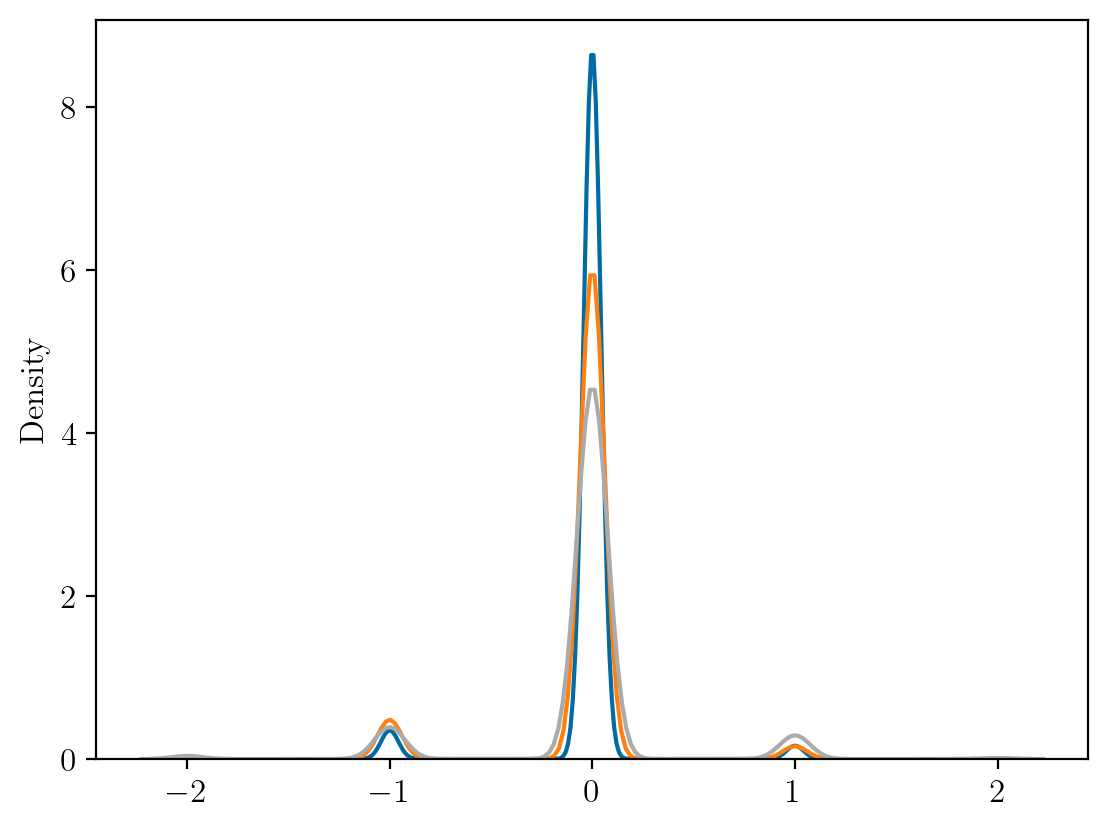

In [ ]:
(p_conv-l_conv)[:,0]

sns.kdeplot((p_conv-l_conv)[:,0])
sns.kdeplot((p_conv-l_conv)[:,1])
sns.kdeplot((p_conv-l_conv)[:,2])

In [25]:
# plt.hist(unks["entropy_of_expected"][l_p==l],density=True)
# plt.hist(unks["entropy_of_expected"][l_p!=l],density=True)